# 02 — Embedding Validation

**Prerequisite**: Run `python scripts/run_sample_pipeline.py` first to generate sample checkpoints.  
**Purpose**: Validate the 1K-sample pipeline output with 3 key visualizations.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.checkpointing import CheckpointManager

OUTPUT_DIR = "../output/embeddings"
cm = CheckpointManager(OUTPUT_DIR)

# Load all sample checkpoints
ta_ids, ta_emb, ta_meta = cm.load_embeddings(f"{OUTPUT_DIR}/sample_title_abstract_embeddings.parquet")
cit_ids, cit_emb, cit_meta = cm.load_embeddings(f"{OUTPUT_DIR}/sample_citation_embeddings.parquet")
cat_ids, cat_emb, cat_meta = cm.load_embeddings(f"{OUTPUT_DIR}/sample_concatenated_1536d.parquet")
umap_ids, umap_emb, umap_meta = cm.load_embeddings(f"{OUTPUT_DIR}/sample_patent_vectors_50d.parquet")

gvkey_map = pd.read_parquet(f"{OUTPUT_DIR}/sample_gvkey_map.parquet")

print(f"Title+abstract: {ta_emb.shape}")
print(f"Citation:       {cit_emb.shape}")
print(f"Concatenated:   {cat_emb.shape}")
print(f"UMAP 50D:       {umap_emb.shape}")
print(f"Unique firms:   {gvkey_map['gvkey'].nunique()}")

Title+abstract: (1000, 768)
Citation:       (1000, 768)
Concatenated:   (1000, 1536)
UMAP 50D:       (1000, 50)
Unique firms:   158


## Visualization 1: 2D UMAP Projection Colored by Firm

Fit a separate 2D UMAP on the 1536D concatenated vectors. Color by gvkey.  
**Expected**: Same-firm patents loosely cluster, but not perfect blobs (firms span multiple tech areas).

/mnt/c/Users/TPata/firm-pair_merger_prediction/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/mnt/c/Users/TPata/firm-pair_merger_prediction/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


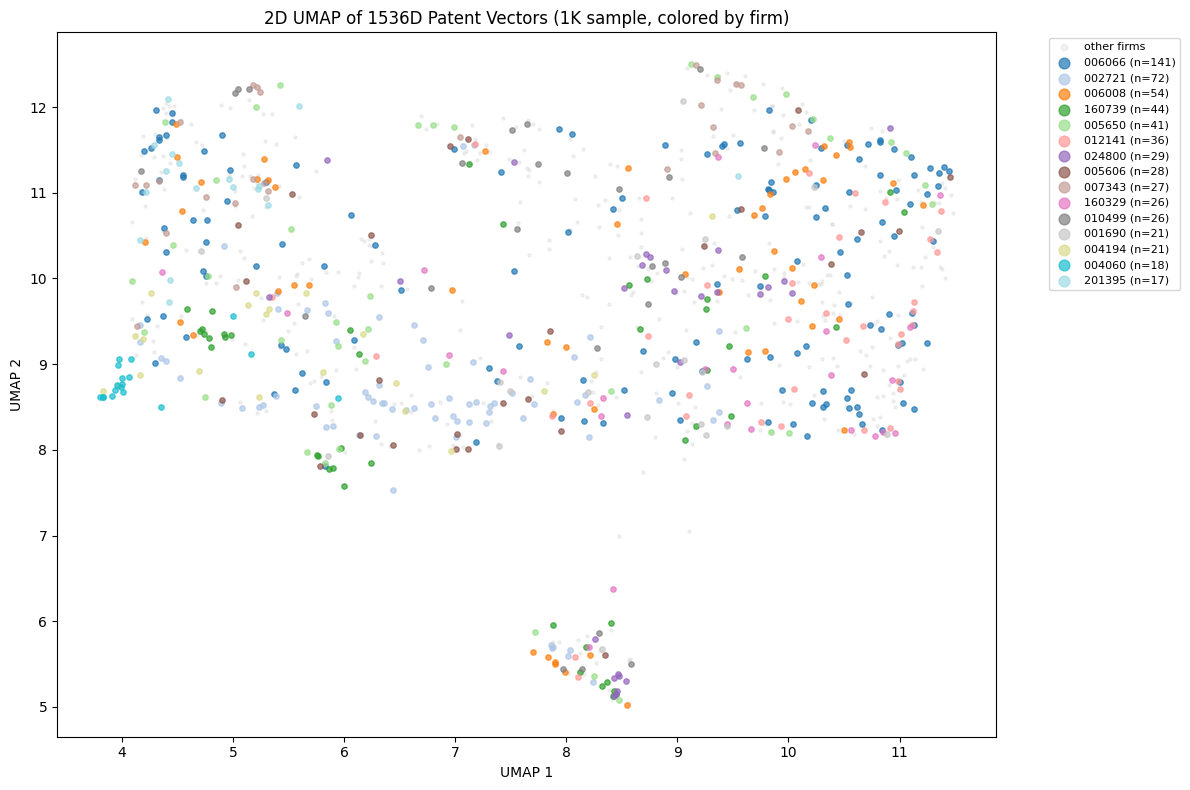

In [2]:
import umap

# Fit 2D UMAP for visualization
reducer_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        metric="cosine", random_state=42)
embedding_2d = reducer_2d.fit_transform(cat_emb)

# Pick top 15 firms by patent count in this sample for coloring
firm_counts = gvkey_map["gvkey"].value_counts()
top_firms = firm_counts.head(15).index.tolist()

fig, ax = plt.subplots(figsize=(12, 8))

# Plot "other" firms in gray first
other_mask = ~gvkey_map["gvkey"].isin(top_firms)
ax.scatter(embedding_2d[other_mask, 0], embedding_2d[other_mask, 1],
           c="lightgray", s=5, alpha=0.3, label="other firms")

# Plot top firms with distinct colors
colors = plt.cm.tab20(np.linspace(0, 1, len(top_firms)))
for firm, color in zip(top_firms, colors):
    mask = gvkey_map["gvkey"] == firm
    n = mask.sum()
    ax.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1],
               c=[color], s=15, alpha=0.7, label=f"{firm} (n={n})")

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("2D UMAP of 1536D Patent Vectors (1K sample, colored by firm)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

## Visualization 2: L2 Norm Histograms

Distribution of L2 norms for title+abstract and citation embeddings.  
**Finding**: PatentSBERTa does NOT L2-normalize output vectors. Title+abstract norms cluster tightly around ~6.8 (std=0.14). Citation norms are bimodal: an upper peak (~6.75) from single-citation patents and a lower peak (~5.5) from multi-citation patents where mean pooling compresses the norm as diverse vectors partially cancel (Pearson r = -0.317 between citation count and norm).

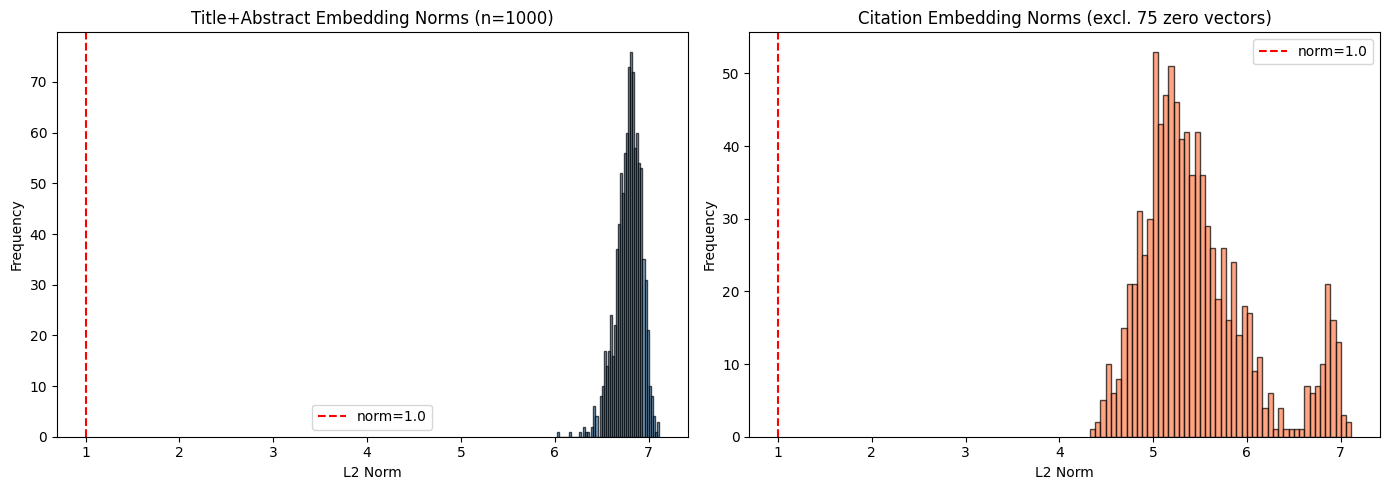

Title+abstract norms: mean=6.7853, std=0.1354
Citation norms (nonzero): mean=5.4641, std=0.5907
Zero-citation patents: 75 (7.5%)


In [3]:
ta_norms = np.linalg.norm(ta_emb, axis=1)
cit_norms = np.linalg.norm(cit_emb, axis=1)

# Separate zero-citation norms
cit_nonzero = cit_norms[cit_norms > 0]
cit_zero_count = (cit_norms == 0).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ta_norms, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].set_xlabel("L2 Norm")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Title+Abstract Embedding Norms (n={len(ta_norms)})")
axes[0].axvline(x=1.0, color="red", linestyle="--", label="norm=1.0")
axes[0].legend()

axes[1].hist(cit_nonzero, bins=50, edgecolor="black", alpha=0.7, color="coral")
axes[1].set_xlabel("L2 Norm")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"Citation Embedding Norms (excl. {cit_zero_count} zero vectors)")
axes[1].axvline(x=1.0, color="red", linestyle="--", label="norm=1.0")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Title+abstract norms: mean={ta_norms.mean():.4f}, std={ta_norms.std():.4f}")
print(f"Citation norms (nonzero): mean={cit_nonzero.mean():.4f}, std={cit_nonzero.std():.4f}")
print(f"Zero-citation patents: {cit_zero_count} ({cit_zero_count/len(cit_norms):.1%})")

## Visualization 3: Pipeline Coverage Statistics

At each pipeline stage, how many patents have valid outputs?  
**Expected**: 100% at title+abstract, ~92% nonzero at citation, 100% at concatenation and UMAP.

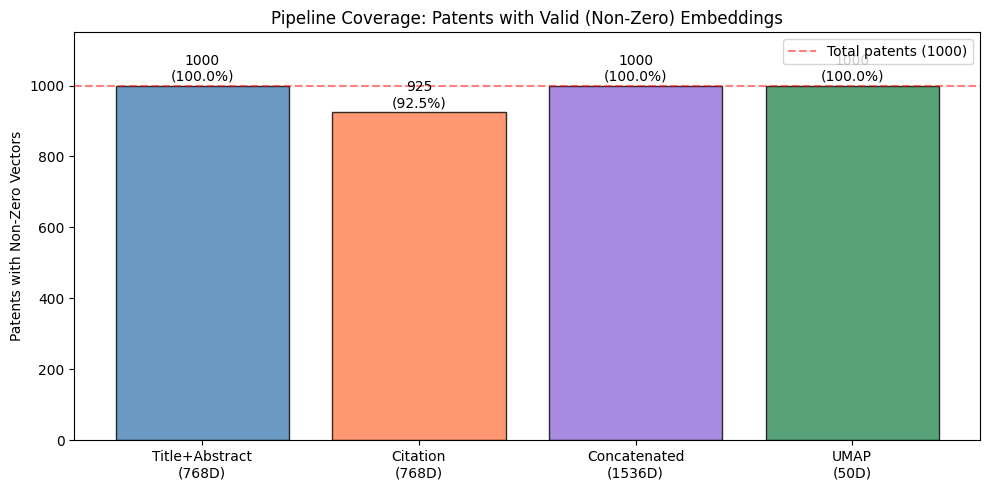

In [4]:
n = len(ta_ids)
ta_valid = (np.linalg.norm(ta_emb, axis=1) > 0).sum()
cit_valid = (np.linalg.norm(cit_emb, axis=1) > 0).sum()
cat_valid = (np.linalg.norm(cat_emb, axis=1) > 0).sum()
umap_valid = (np.linalg.norm(umap_emb, axis=1) > 0).sum()

stages = ["Title+Abstract\n(768D)", "Citation\n(768D)", "Concatenated\n(1536D)", "UMAP\n(50D)"]
counts = [ta_valid, cit_valid, cat_valid, umap_valid]
pcts = [c / n * 100 for c in counts]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(stages, counts, color=["steelblue", "coral", "mediumpurple", "seagreen"],
              edgecolor="black", alpha=0.8)
ax.axhline(y=n, color="red", linestyle="--", alpha=0.5, label=f"Total patents ({n})")

for bar, pct, count in zip(bars, pcts, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{count}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Patents with Non-Zero Vectors")
ax.set_title("Pipeline Coverage: Patents with Valid (Non-Zero) Embeddings")
ax.legend()
ax.set_ylim(0, n * 1.15)
plt.tight_layout()
plt.show()

## Summary

**Validation results** (1K sample, CPU, 13.4 min):

- [x] 2D UMAP shows meaningful structure — clear spatial variation with a distinct lower-right cluster, not random noise or a single blob
- [x] Same-firm patents show clustering tendencies — focused-portfolio firms cluster tighter, mega-firms (e.g., 006066/IBM) span the space as expected
- [x] Title+abstract L2 norms are tightly distributed (mean=6.79, std=0.14) — consistent, no degenerate vectors. PatentSBERTa does NOT unit-normalize (this is fine; UMAP uses cosine metric)
- [x] Citation L2 norms are bimodal: upper peak ~6.75 (1-3 citations), lower peak ~5.5 (4+ citations). This is an expected property of mean pooling over varying citation counts (r=-0.317). 75 zero vectors (7.5%) from zero-citation patents.
- [x] Coverage: 100% at title+abstract, 92.5% nonzero at citation, 100% at concatenation and UMAP — no patents lost
- [x] All 4 checkpoint files exist and are loadable with correct shapes and metadata
- [x] Pipeline completed without errors

**Implications for Week 2**: Embeddings are ready for GMM portfolio fitting. The non-normalized norms and bimodal citation distribution are well-understood and documented in ADR-001 and ADR-002. Normalize before GMM if scale-sensitivity is a concern.